# MNIST with XGBoost

This complete workflow provides the framework-neutral tree-model comparison from
[Tree Models and Ensembles](../index.md). It uses the same seed-42 split and
classification evidence as the neural examples.

In Colab, run all cells; the first import cell installs XGBoost only if it is
missing. Reduce `ROUNDS` below if you want a quicker run.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {}
COLAB_EXTRAS = {'xgboost': 'xgboost'}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and shared split

In [3]:
import hashlib
import gzip
import importlib.util
import json
import os
import struct
import subprocess
import sys
from pathlib import Path
from urllib.request import urlopen

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost>=2.1,<4"])

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

SEED = 42
raw_root = Path(
    os.getenv("HELIO_DATA_DIR", Path.home() / ".cache" / "helio-data-methods" / "torchvision")
) / "MNIST" / "raw"
raw_root.mkdir(parents=True, exist_ok=True)
mnist_files = {
    "train-images-idx3-ubyte.gz": "440fcabf73cc546fa21475e81ea370265605f56be210a4024d2ca8f203523609",
    "train-labels-idx1-ubyte.gz": "3552534a0a558bbed6aed32b30c495cca23d567ec52cac8be1a0730e8010255c",
    "t10k-images-idx3-ubyte.gz": "8d422c7b0a1c1c79245a5bcf07fe86e33eeafee792b84584aec276f5a2dbc4e6",
    "t10k-labels-idx1-ubyte.gz": "f7ae60f92e00ec6debd23a6088c31dbd2371eca3ffa0defaefb259924204aec6",
}


def fetch_mnist_file(filename, checksum):
    destination = raw_root / filename
    if not destination.exists():
        url = f"https://ossci-datasets.s3.amazonaws.com/mnist/{filename}"
        with urlopen(url, timeout=60) as response:
            destination.write_bytes(response.read())
    actual = hashlib.sha256(destination.read_bytes()).hexdigest()
    if actual != checksum:
        raise RuntimeError(f"MNIST checksum mismatch for {filename}: {actual}")
    return destination


def read_images(path):
    with gzip.open(path, "rb") as stream:
        magic, count, rows, columns = struct.unpack(">IIII", stream.read(16))
        if magic != 2051:
            raise RuntimeError(f"unexpected MNIST image magic number: {magic}")
        return np.frombuffer(stream.read(), dtype=np.uint8).reshape(count, rows, columns)


def read_labels(path):
    with gzip.open(path, "rb") as stream:
        magic, count = struct.unpack(">II", stream.read(8))
        if magic != 2049:
            raise RuntimeError(f"unexpected MNIST label magic number: {magic}")
        return np.frombuffer(stream.read(), dtype=np.uint8, count=count)


resolved_mnist = {
    filename: fetch_mnist_file(filename, checksum)
    for filename, checksum in mnist_files.items()
}
import xgboost as xgb

x_development = read_images(resolved_mnist["train-images-idx3-ubyte.gz"])
y_development = read_labels(resolved_mnist["train-labels-idx1-ubyte.gz"])
x_test = read_images(resolved_mnist["t10k-images-idx3-ubyte.gz"])
y_test = read_labels(resolved_mnist["t10k-labels-idx1-ubyte.gz"])
indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    indices, test_size=10_000, random_state=SEED, stratify=y_development
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]
x_train = x_development[train_indices].reshape(len(train_indices), -1).astype("float32") / 255
y_train = y_development[train_indices]
x_validation = (
    x_development[validation_indices].reshape(len(validation_indices), -1).astype("float32") / 255
)
y_validation = y_development[validation_indices]
x_test = x_test.reshape(len(x_test), -1).astype("float32") / 255
print(f"XGBoost {xgb.__version__}; split signature: {split_signature}")

XGBoost 2.1.4; split signature: 829d1431018b38bc


## Inspect the training distribution

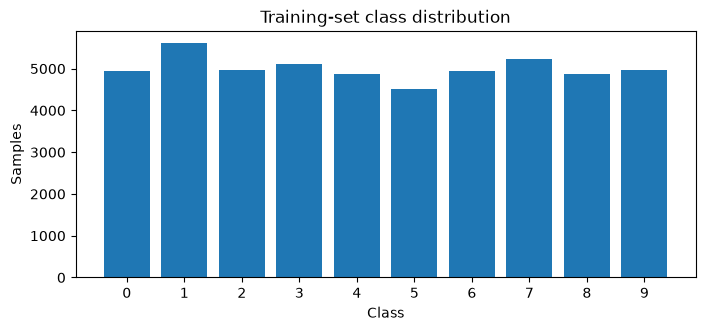

In [4]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Train with validation-only early stopping

In [5]:
parameters = {
    "objective": "multi:softprob",
    "num_class": 10,
    "eta": 0.08,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "alpha": 8,
    "lambda": 2,
    "eval_metric": "merror",
    "seed": SEED,
    "nthread": 2,
}
ROUNDS = 100  # Reduce to 10 or 25 for a quicker run.
dtrain = xgb.DMatrix(x_train, label=y_train)
dvalidation = xgb.DMatrix(x_validation, label=y_validation)
model = xgb.train(
    parameters,
    dtrain,
    num_boost_round=ROUNDS,
    evals=[(dtrain, "training"), (dvalidation, "validation")],
    early_stopping_rounds=10,
    verbose_eval=10,
)

[0]	training-merror:0.13948	validation-merror:0.15640


[10]	training-merror:0.07366	validation-merror:0.08920


[20]	training-merror:0.06042	validation-merror:0.07510


[30]	training-merror:0.05090	validation-merror:0.06560


[40]	training-merror:0.04400	validation-merror:0.06030


...

[60]	training-merror:0.03348	validation-merror:0.05330


[70]	training-merror:0.02918	validation-merror:0.05000


[80]	training-merror:0.02570	validation-merror:0.04670


[90]	training-merror:0.02292	validation-merror:0.04430


[99]	training-merror:0.02052	validation-merror:0.04200


## Final test evidence

test accuracy: 0.9605
              precision    recall  f1-score   support

           0      0.964     0.987     0.975       980
           1      0.985     0.986     0.985      1135
           2      0.955     0.954     0.955      1032
           3      0.950     0.959     0.955      1010
           4      0.970     0.956     0.963       982
           5      0.965     0.947     0.956       892
           6      0.966     0.967     0.966       958
           7      0.968     0.945     0.956      1028
           8      0.948     0.949     0.948       974
           9      0.933     0.951     0.942      1009

    accuracy                          0.961     10000
   macro avg      0.960     0.960     0.960     10000
weighted avg      0.961     0.961     0.960     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "829d1431018b38bc", "test_accuracy": 0.9605}


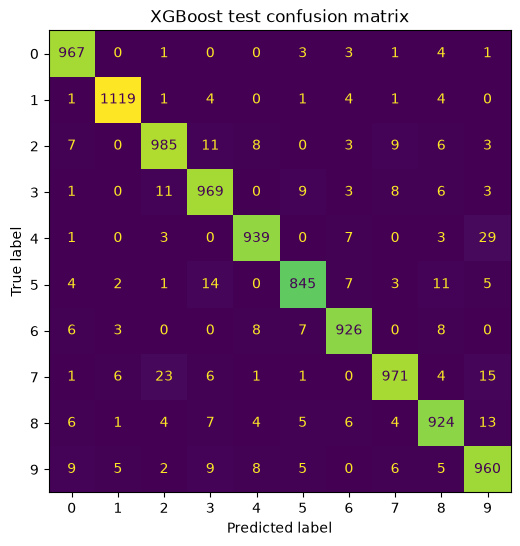

In [6]:
probabilities = model.predict(xgb.DMatrix(x_test))
test_predictions = probabilities.argmax(axis=1)
test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, test_predictions, digits=3, zero_division=0))
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("XGBoost test confusion matrix")
plt.show()

## Example thought

How does maximum tree depth affect validation error and runtime? The two
models below use the same training and validation samples and the same
50-round ceiling. The final test set is not used in this comparison.

In [7]:
EXAMPLE_ROUNDS = 50  # Reduce to 10 or 25 for a quicker comparison.
EXAMPLE_DEPTHS = [3, 6]
print(f"depths: {EXAMPLE_DEPTHS}; round ceiling={EXAMPLE_ROUNDS}")

depths: [3, 6]; round ceiling=50


In [8]:
import time
import pandas as pd


def run_depth_example(depth):
    candidate_parameters = dict(parameters)
    candidate_parameters["max_depth"] = depth
    started = time.perf_counter()
    candidate = xgb.train(
        candidate_parameters,
        dtrain,
        num_boost_round=EXAMPLE_ROUNDS,
        evals=[(dvalidation, "validation")],
        early_stopping_rounds=10,
        verbose_eval=False,
    )
    predictions = candidate.predict(dvalidation).argmax(axis=1)
    return {
        "configuration": f"depth={depth}",
        "validation_error": float(1.0 - accuracy_score(y_validation, predictions)),
        "runtime_seconds": float(time.perf_counter() - started),
        "boosting_rounds": int(candidate.best_iteration + 1),
        "max_depth": depth,
    }

,configuration,validation_error,runtime_seconds,boosting_rounds,max_depth
0,depth=3,0.1074,60.199683,50,3
1,depth=6,0.0569,77.738924,50,6


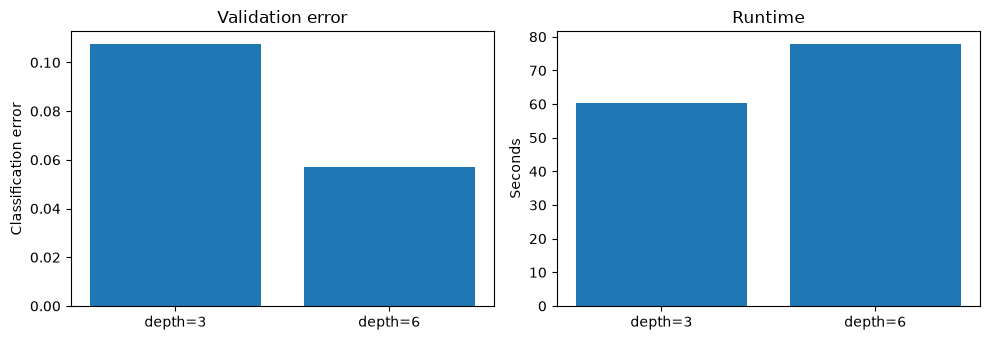

HELIO_EXPERIMENT {"budget": {"mode": "compact", "rounds": 50}, "comparison_metrics": ["validation_error", "runtime_seconds", "boosting_rounds"], "configurations": [{"boosting_rounds": 50, "configuration": "depth=3", "max_depth": 3, "runtime_seconds": 60.19968333397992, "validation_error": 0.10740000000000005}, {"boosting_rounds": 50, "configuration": "depth=6", "max_depth": 6, "runtime_seconds": 77.73892437497852, "validation_error": 0.05689999999999995}], "experiment_id": "maximum-tree-depth", "test_used": false}


In [9]:
example_results = [run_depth_example(depth) for depth in EXAMPLE_DEPTHS]
example_table = pd.DataFrame(example_results)
display(example_table)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(example_table["configuration"], example_table["validation_error"])
axes[0].set(title="Validation error", ylabel="Classification error")
axes[1].bar(example_table["configuration"], example_table["runtime_seconds"])
axes[1].set(title="Runtime", ylabel="Seconds")
plt.tight_layout()
plt.show()

experiment_evidence = {
    "experiment_id": "maximum-tree-depth",
    "configurations": example_table.to_dict(orient="records"),
    "budget": {"rounds": EXAMPLE_ROUNDS, "mode": "compact"},
    "comparison_metrics": ["validation_error", "runtime_seconds", "boosting_rounds"],
    "test_used": False,
}
print("HELIO_EXPERIMENT " + json.dumps(experiment_evidence, sort_keys=True))

## Try it yourself

- Try depths 2, 4, and 8 and compare validation error with runtime.
- Hold depth fixed and vary the learning rate between `0.03` and `0.15`.
- Change `subsample` from `0.8` to `0.6` or `1.0` and inspect stability.